In [1]:
import wfdb
import neurokit2 as nk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("All imports OK")

for infant in range (1, 11):

    record = wfdb.rdrecord(
        rf'C:\Users\Asus\OneDrive\Desktop\neopain-research\data\raw\PICS\infant{infant}_ecg'
    )

    print(f"Signal names : {record.sig_name}")
    print(f"Sampling rate: {record.fs} Hz")
    print(f"Duration     : {record.sig_len / record.fs / 3600:.1f} hours")
    print(f"Signal shape : {record.p_signal.shape}")      
    print("\n \n")       


All imports OK
Signal names : ['ECG']
Sampling rate: 250 Hz
Duration     : 45.6 hours
Signal shape : (41052191, 1)

 

Signal names : ['II']
Sampling rate: 500 Hz
Duration     : 43.8 hours
Signal shape : (78916000, 1)

 

Signal names : ['II']
Sampling rate: 500 Hz
Duration     : 43.7 hours
Signal shape : (78684614, 1)

 

Signal names : ['II']
Sampling rate: 500 Hz
Duration     : 46.8 hours
Signal shape : (84208000, 1)

 

Signal names : ['ECG']
Sampling rate: 250 Hz
Duration     : 48.8 hours
Signal shape : (43878723, 1)

 

Signal names : ['II']
Sampling rate: 500 Hz
Duration     : 48.6 hours
Signal shape : (87492197, 1)

 

Signal names : ['II']
Sampling rate: 500 Hz
Duration     : 20.3 hours
Signal shape : (36604500, 1)

 

Signal names : ['II']
Sampling rate: 500 Hz
Duration     : 24.6 hours
Signal shape : (44288000, 1)

 

Signal names : ['II']
Sampling rate: 500 Hz
Duration     : 70.3 hours
Signal shape : (126569088, 1)

 

Signal names : ['I']
Sampling rate: 500 Hz
Duration    

In [2]:
import os

pics_folder = r'C:\Users\Asus\OneDrive\Desktop\neopain-research\data\raw\PICS'
all_files = sorted(os.listdir(pics_folder))

print(f"Total files: {len(all_files)}")
print("\n--- All files ---")
for f in all_files:
    print(f)

Total files: 73

--- All files ---
ANNOTATORS
RECORDS
SHA256SUMS.txt
infant10_ecg.atr
infant10_ecg.dat
infant10_ecg.hea
infant10_ecg.qrsc
infant10_resp.dat
infant10_resp.hea
infant10_resp.resp
infant1_ecg.atr
infant1_ecg.dat
infant1_ecg.hea
infant1_ecg.qrsc
infant1_resp.dat
infant1_resp.hea
infant1_resp.resp
infant2_ecg.atr
infant2_ecg.dat
infant2_ecg.hea
infant2_ecg.qrsc
infant2_resp.dat
infant2_resp.hea
infant2_resp.resp
infant3_ecg.atr
infant3_ecg.dat
infant3_ecg.hea
infant3_ecg.qrsc
infant3_resp.dat
infant3_resp.hea
infant3_resp.resp
infant4_ecg.atr
infant4_ecg.dat
infant4_ecg.hea
infant4_ecg.qrsc
infant4_resp.dat
infant4_resp.hea
infant4_resp.resp
infant5_ecg.atr
infant5_ecg.dat
infant5_ecg.hea
infant5_ecg.qrsc
infant5_resp.dat
infant5_resp.hea
infant5_resp.resp
infant6_ecg.atr
infant6_ecg.dat
infant6_ecg.hea
infant6_ecg.qrsc
infant6_resp.dat
infant6_resp.hea
infant6_resp.resp
infant7_ecg.atr
infant7_ecg.dat
infant7_ecg.hea
infant7_ecg.qrsc
infant7_resp.dat
infant7_resp.hea
infant

ECG signal shape: (78684614,), Sampling rate: 500 Hz ,Ecg  -fs :500 Hz , lentgh: 78684614 samples
Resp signal shape: (7868296,), Sampling rate: 50 Hz ,Resp  -fs :50 Hz , lentgh: 7868296 samples


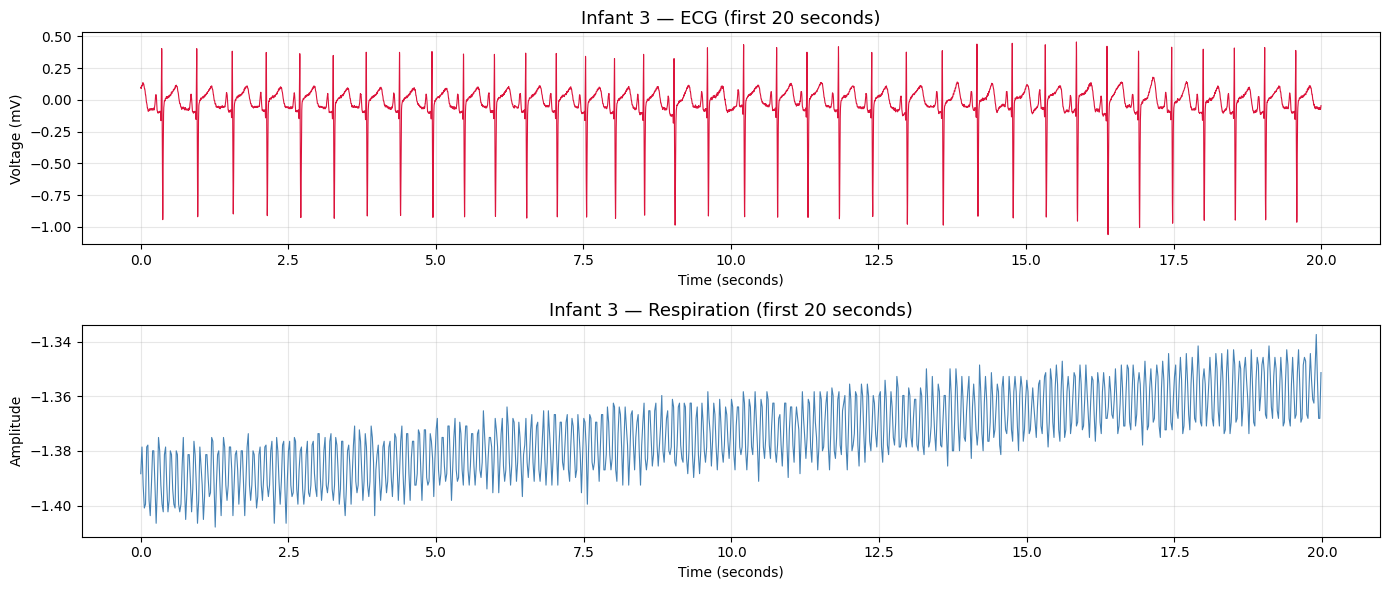

Plot saved to outputs/figures/


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import neurokit2 as nk
import wfdb as wfdb
import scipy.signal as signal 


pics_path = r'C:\Users\Asus\OneDrive\Desktop\neopain-research\data\raw\PICS'

ecg_record = wfdb.rdrecord(f'{pics_path}\\infant3_ecg')
ecg_signal = ecg_record.p_signal[:,0]
fs_ecg = ecg_record.fs

resp_record = wfdb.rdrecord(f'{pics_path}\\infant3_resp')
resp_signal = resp_record.p_signal[:,0]
fs_resp = resp_record.fs

print(f"ECG signal shape: {ecg_signal.shape}, Sampling rate: {fs_ecg} Hz ,Ecg  -fs :{fs_ecg} Hz , lentgh: {len(ecg_signal)} samples")
print(f"Resp signal shape: {resp_signal.shape}, Sampling rate: {fs_resp} Hz ,Resp  -fs :{fs_resp} Hz , lentgh: {len(resp_signal)} samples")


# Plot first 20 seconds of both signals
fig, axes = plt.subplots(2, 1, figsize=(14, 6))

# 20 seconds worth of samples
ecg_20s  = ecg_signal[:20 * fs_ecg]
resp_20s = resp_signal[:20 * fs_resp]

time_ecg  = np.arange(len(ecg_20s))  / fs_ecg   #converts sample numbers into actual seconds
time_resp = np.arange(len(resp_20s)) / fs_resp  #converts sample numbers into actual seconds

axes[0].plot(time_ecg,  ecg_20s,  color='crimson', linewidth=0.8)
axes[0].set_title('Infant 3 — ECG (first 20 seconds)', fontsize=13)
axes[0].set_xlabel('Time (seconds)')
axes[0].set_ylabel('Voltage (mV)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(time_resp, resp_20s, color='steelblue', linewidth=0.8)
axes[1].set_title('Infant 3 — Respiration (first 20 seconds)', fontsize=13)
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('Amplitude')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(r'C:\Users\Asus\OneDrive\Desktop\neopain-research\outputs\figures\infant3_raw_signals.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to outputs/figures/")



ECG  — fs: 500 Hz, length: 78684614 samples (43.7 hours)
RESP — fs: 50 Hz, length: 7868296 samples

Total R-peaks detected in full recording: 328657
Average heart rate: 125.3 bpm

Plot saved to outputs/figures/infant3_ecg_resp_peaks.png


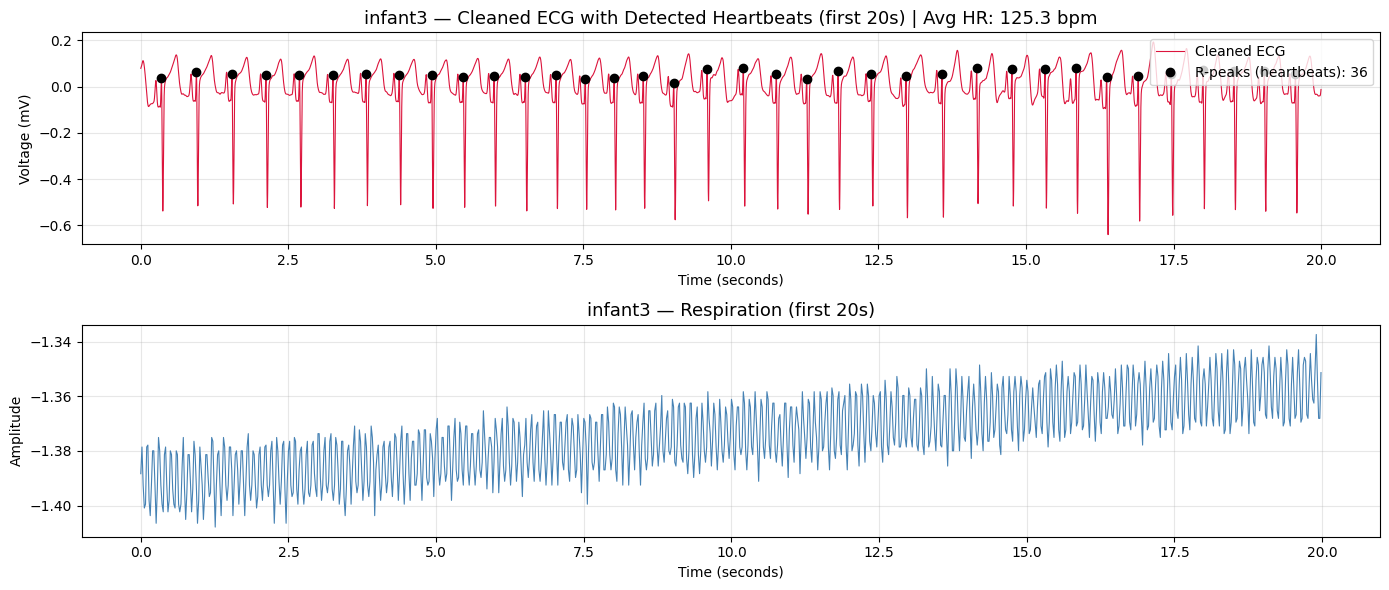

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import neurokit2 as nk
import wfdb

# ── Setup ──────────────────────────────────────────────────────────────
pics_path = r"C:\Users\Asus\OneDrive\Desktop\neopain-research\data\raw\PICS"
infant_id = "infant3"

# ── Load signals ──────────────────────────────────────────────────────
ecg_record = wfdb.rdrecord(f"{pics_path}\\{infant_id}_ecg")
ecg_signal = ecg_record.p_signal[:, 0]
fs_ecg = ecg_record.fs

resp_record = wfdb.rdrecord(f"{pics_path}\\{infant_id}_resp")
resp_signal = resp_record.p_signal[:, 0]
fs_resp = resp_record.fs

print(f"ECG  — fs: {fs_ecg} Hz, length: {len(ecg_signal)} samples "
      f"({len(ecg_signal)/fs_ecg/3600:.1f} hours)")
print(f"RESP — fs: {fs_resp} Hz, length: {len(resp_signal)} samples")

# ── Clean ECG (fast — just filtering, not full ecg_process) ─────────────
ecg_cleaned = nk.ecg_clean(ecg_signal, sampling_rate=fs_ecg)

# ── Fast R-peak detection on FULL signal ────────────────────────────────
_, info = nk.ecg_peaks(ecg_cleaned, sampling_rate=fs_ecg)
r_peaks = info['ECG_R_Peaks']

total_hours = len(ecg_signal) / fs_ecg / 3600
avg_hr = len(r_peaks) / (len(ecg_signal) / fs_ecg / 60)    #hr = heartrate

print(f"\nTotal R-peaks detected in full recording: {len(r_peaks)}")
print(f"Average heart rate: {avg_hr:.1f} bpm")

# ── Visualize first 20 seconds — both signals + detected peaks ──────────
window_sec = 20
ecg_window  = ecg_cleaned[:window_sec * fs_ecg]
resp_window = resp_signal[:window_sec * fs_resp]

time_ecg  = np.arange(len(ecg_window))  / fs_ecg
time_resp = np.arange(len(resp_window)) / fs_resp

# Only keep R-peaks that fall within this 20-second window
peaks_in_window = [p for p in r_peaks if p < window_sec * fs_ecg]

fig, axes = plt.subplots(2, 1, figsize=(14, 6))

# --- ECG panel with detected R-peaks ---
axes[0].plot(time_ecg, ecg_window, color="crimson", linewidth=0.8, label="Cleaned ECG")
axes[0].plot(
    np.array(peaks_in_window) / fs_ecg,
    ecg_window[peaks_in_window],
    "ko", markersize=6,
    label=f"R-peaks (heartbeats): {len(peaks_in_window)}"
)
axes[0].set_title(f"{infant_id} — Cleaned ECG with Detected Heartbeats "
                   f"(first {window_sec}s) | Avg HR: {avg_hr:.1f} bpm", fontsize=13)
axes[0].set_xlabel("Time (seconds)")
axes[0].set_ylabel("Voltage (mV)")
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc="upper right")

# --- Respiration panel ---
axes[1].plot(time_resp, resp_window, color="steelblue", linewidth=0.8)
axes[1].set_title(f"{infant_id} — Respiration (first {window_sec}s)", fontsize=13)
axes[1].set_xlabel("Time (seconds)")
axes[1].set_ylabel("Amplitude")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    rf"C:\Users\Asus\OneDrive\Desktop\neopain-research\outputs\figures\{infant_id}_ecg_resp_peaks.png",
    dpi=150, bbox_inches="tight"
)
print(f"\nPlot saved to outputs/figures/{infant_id}_ecg_resp_peaks.png")

In [ ]:
import neurokit2 as nk
import numpy as np

# Take only the R-peaks within the first 5 minutes
secs = 600 
chunk_sec = 5 * secs  # 50 minutes
chunk_samples = chunk_sec * fs_ecg

r_peaks_chunk = r_peaks[r_peaks < chunk_samples]
print(f"R-peaks in first {chunk_sec}s: {len(r_peaks_chunk)}")

# Compute HRV on this chunk only
hrv_indices = nk.hrv(r_peaks_chunk, sampling_rate=fs_ecg, show=False)

key_features = ['HRV_MeanNN', 'HRV_SDNN', 'HRV_RMSSD', 'HRV_LF', 'HRV_HF', 'HRV_LFHF']
print(hrv_indices[key_features].T)                       

mean_nn_seconds = hrv_indices["HRV_MeanNN"].values[0] / 1000
Heartrate = 60 / mean_nn_seconds
print(f"Estimated Heart Rate from MeanNN: {Heartrate:.2f} bpm")

R-peaks in first 3000s: 5950
                     0
HRV_MeanNN  504.197008
HRV_SDNN     32.657567
HRV_RMSSD    30.884800
HRV_LF        0.022366
HRV_HF        0.028761
HRV_LFHF      0.777637
Estimated Heart Rate from MeanNN: 119.00 bpm


In [6]:
import neurokit2 as nk
import numpy as np
import pandas as pd

def extract_hrv_features_windowed(ecg_signal, fs_ecg, window_sec=60, step_sec=60):
    """
    Slides a window across the ECG signal, detects R-peaks per window,
    and computes HRV features for each window.

    Returns a DataFrame: one row per window.
    """
    window_samples = window_sec * fs_ecg
    step_samples = step_sec * fs_ecg
    total_samples = len(ecg_signal)

    # Clean the full signal once (fast)
    ecg_cleaned = nk.ecg_clean(ecg_signal, sampling_rate=fs_ecg)

    # Detect R-peaks once on the full signal (fast)
    _, info = nk.ecg_peaks(ecg_cleaned, sampling_rate=fs_ecg)
    r_peaks_all = info['ECG_R_Peaks']

    results = []
    n_windows = (total_samples - window_samples) // step_samples + 1

    for i in range(n_windows):
        start = i * step_samples
        end = start + window_samples

        # R-peaks falling inside this window
        window_peaks = r_peaks_all[(r_peaks_all >= start) & (r_peaks_all < end)]

        # Need at least a few beats to compute HRV
        if len(window_peaks) < 5:
            continue

        # Shift peaks to be relative to window start (required by nk.hrv)
        relative_peaks = window_peaks - start

        try:
            hrv = nk.hrv_time(relative_peaks, sampling_rate=fs_ecg, show=False)
            row = {
                'window_idx': i,
                'start_sec': start / fs_ecg,
                'end_sec': end / fs_ecg,
                'n_beats': len(window_peaks),
                'HRV_MeanNN': hrv['HRV_MeanNN'].values[0],
                'HRV_SDNN': hrv['HRV_SDNN'].values[0],
                'HRV_RMSSD': hrv['HRV_RMSSD'].values[0],
                'HRV_pNN50': hrv['HRV_pNN50'].values[0],
            }
            results.append(row)
        except Exception:
            continue

    return pd.DataFrame(results)


# Test it on infant3 — first run on a small subset to verify speed
test_signal = ecg_signal[:30 * 60 * fs_ecg]  # first 30 minutes only
features_df = extract_hrv_features_windowed(test_signal, fs_ecg, window_sec=60, step_sec=60)

print(f"Generated {len(features_df)} windows")
print(features_df.head(20))

Generated 30 windows
    window_idx  start_sec  end_sec  n_beats  HRV_MeanNN   HRV_SDNN  HRV_RMSSD  \
0            0        0.0     60.0      111  540.290909  47.405211  46.832514   
1            1       60.0    120.0      116  516.678261  30.058291  14.580689   
2            2      120.0    180.0      115  521.508772  24.717249  15.512484   
3            3      180.0    240.0      117  513.844828  49.115410  63.587530   
4            4      240.0    300.0      118  509.076923  25.650890  10.218307   
5            5      300.0    360.0      114  526.159292  21.827475  13.248989   
6            6      360.0    420.0      119  502.372881  19.093918  12.134573   
7            7      420.0    480.0      116  517.704348  24.995780   9.817635   
8            8      480.0    540.0      119  504.508475  27.055102  10.135830   
9            9      540.0    600.0      119  505.288136  19.207416   8.674553   
10          10      600.0    660.0      121  494.583333  14.021342   6.138458   
11     

In [7]:
# Cell 7 — Full recording HRV extraction for infant1
features_df_full = extract_hrv_features_windowed(ecg_signal, fs_ecg, window_sec=60, step_sec=60)
print(f"Total windows for infant1: {len(features_df_full)}")
print(features_df_full.describe().round(2))  # summary stats of all windows
features_df_full.to_csv(
    r'C:\Users\Asus\OneDrive\Desktop\neopain-research\data\processed\infant1_hrv_features.csv',
    index=False
)
print("Saved to data/processed/infant1_hrv_features.csv")

Total windows for infant1: 2584
       window_idx  start_sec    end_sec  n_beats  HRV_MeanNN  HRV_SDNN  \
count     2584.00    2584.00    2584.00  2584.00     2584.00   2584.00   
mean      1320.18   79211.08   79271.08   127.15      474.46     49.82   
std        754.73   45284.05   45284.05     9.27       59.51    227.90   
min          0.00       0.00      60.00    22.00      362.99      3.53   
25%        675.75   40545.00   40605.00   122.00      454.63     14.55   
50%       1321.50   79290.00   79350.00   127.00      473.18     21.62   
75%       1975.25  118515.00  118575.00   132.00      491.77     42.09   
max       2621.00  157260.00  157320.00   163.00     2826.48  10111.40   

       HRV_RMSSD  HRV_pNN50  
count    2584.00    2584.00  
mean       51.88       4.89  
std       315.51      10.30  
min         2.25       0.00  
25%         6.90       0.00  
50%        11.42       0.00  
75%        36.74       4.24  
max     14702.77      86.11  
Saved to data/processed/infant1

In [8]:
# Cell 8 — Extract HRV features for ALL 10 infants
import wfdb
import pandas as pd
import os

pics_path = r"C:\Users\Asus\OneDrive\Desktop\neopain-research\data\raw\PICS"
save_path = r"C:\Users\Asus\OneDrive\Desktop\neopain-research\data\processed"
os.makedirs(save_path, exist_ok=True)

all_features = []

for i in range(1, 11):
    infant_id = f"infant{i}"
    try:
        ecg_record = wfdb.rdrecord(f"{pics_path}\\{infant_id}_ecg")
        ecg_signal_i = ecg_record.p_signal[:, 0]
        fs_ecg_i = ecg_record.fs

        df = extract_hrv_features_windowed(ecg_signal_i, fs_ecg_i, window_sec=60, step_sec=60)
        df['infant_id'] = infant_id
        all_features.append(df)
        print(f"{infant_id}: {len(df)} windows | "
              f"avg HR: {60000/df['HRV_MeanNN'].mean():.1f} bpm | "
              f"avg RMSSD: {df['HRV_RMSSD'].mean():.1f} ms")
    except Exception as e:
        print(f"{infant_id}: FAILED — {e}")

combined_df = pd.concat(all_features, ignore_index=True)
combined_df.to_csv(f"{save_path}\\all_infants_hrv_features.csv", index=False)

print(f"\nDone. Total windows: {len(combined_df)}")
print(combined_df['infant_id'].value_counts().sort_index())


infant1: 2728 windows | avg HR: 152.5 bpm | avg RMSSD: 22.9 ms
infant2: 2595 windows | avg HR: 125.8 bpm | avg RMSSD: 52.6 ms
infant3: 2584 windows | avg HR: 126.5 bpm | avg RMSSD: 51.9 ms
infant4: 2804 windows | avg HR: 164.3 bpm | avg RMSSD: 22.9 ms
infant5: 2879 windows | avg HR: 118.4 bpm | avg RMSSD: 221.0 ms
infant6: 2911 windows | avg HR: 133.2 bpm | avg RMSSD: 51.2 ms
infant7: 1212 windows | avg HR: 150.8 bpm | avg RMSSD: 95.0 ms
infant8: 1462 windows | avg HR: 139.1 bpm | avg RMSSD: 17.9 ms
infant9: 4206 windows | avg HR: 147.0 bpm | avg RMSSD: 22.2 ms
infant10: 2827 windows | avg HR: 144.3 bpm | avg RMSSD: 90.9 ms

Done. Total windows: 26208
infant_id
infant1     2728
infant10    2827
infant2     2595
infant3     2584
infant4     2804
infant5     2879
infant6     2911
infant7     1212
infant8     1462
infant9     4206
Name: count, dtype: int64


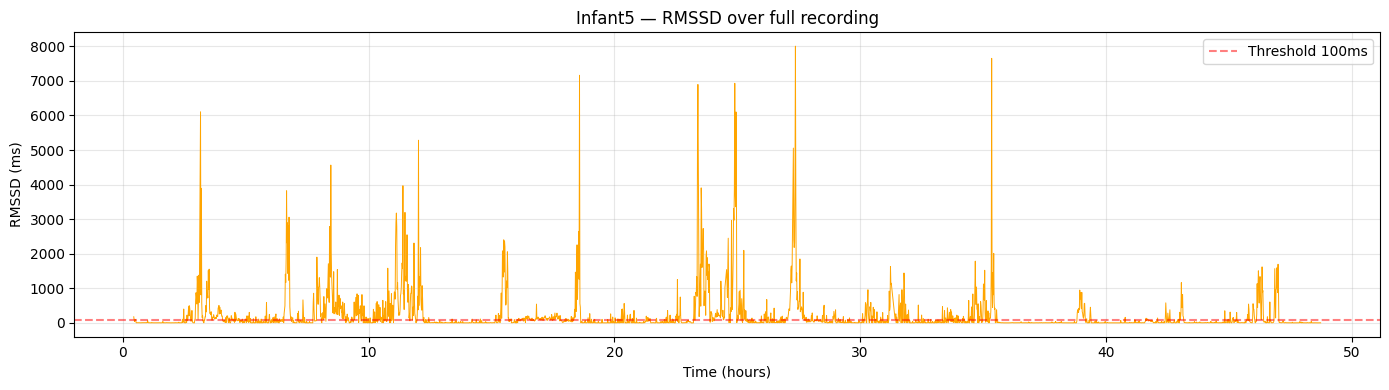

count    2879.00
mean      221.04
std       598.11
min         3.20
25%         6.32
50%        18.92
75%       148.42
max      8002.39
Name: HRV_RMSSD, dtype: float64


: 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

combined_df = pd.read_csv(
    r'C:\Users\Asus\OneDrive\Desktop\neopain-research\data\processed\all_infants_hrv_features.csv'
)

# Plot RMSSD over time for infant5 specifically
infant5 = combined_df[combined_df['infant_id'] == 'infant5']

plt.figure(figsize=(14, 4))
plt.plot(infant5['start_sec'] / 3600, infant5['HRV_RMSSD'],
         color='orange', linewidth=0.7)
plt.axhline(y=100, color='red', linestyle='--', alpha=0.5, label='Threshold 100ms')
plt.title('Infant5 — RMSSD over full recording')
plt.xlabel('Time (hours)')
plt.ylabel('RMSSD (ms)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(infant5['HRV_RMSSD'].describe().round(2))